### Import Libraries

In [1]:
# Import required libraries for decision tree classification
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


### Load Iris Dataset

In [4]:
# Load iris dataset
df = pd.read_csv('1) iris.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Explore Dataset

In [5]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['species'].value_counts())

print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Basic Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.1

### Prepare Features and Target

In [6]:
# Separate features and target
X = df.drop('species', axis=1)
y = df['species']

# Encode target labels to numeric values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name} -> {i}")

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y_encoded.shape}")

Class mapping:
  setosa -> 0
  versicolor -> 1
  virginica -> 2

Features shape: (150, 4)
Target shape: (150,)


### Split Dataset

In [7]:
# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("=== Dataset Split ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

=== Dataset Split ===
Training samples: 120
Testing samples: 30


### Train Unpruned Decision Tree

In [8]:
# Train unpruned decision tree (no depth limit)
tree_unpruned = DecisionTreeClassifier(random_state=42)
tree_unpruned.fit(X_train, y_train)

# Evaluate unpruned tree
y_pred_unpruned = tree_unpruned.predict(X_test)
acc_unpruned = accuracy_score(y_test, y_pred_unpruned)
f1_unpruned = f1_score(y_test, y_pred_unpruned, average='weighted')

print("=== Unpruned Tree Performance ===")
print(f"Accuracy: {acc_unpruned:.4f}")
print(f"F1-Score (weighted): {f1_unpruned:.4f}")
print(f"Tree depth: {tree_unpruned.tree_.max_depth}")
print(f"Number of leaves: {tree_unpruned.tree_.n_leaves}")

=== Unpruned Tree Performance ===
Accuracy: 0.9333
F1-Score (weighted): 0.9333
Tree depth: 5
Number of leaves: 8


### Visualize Unpruned Tree

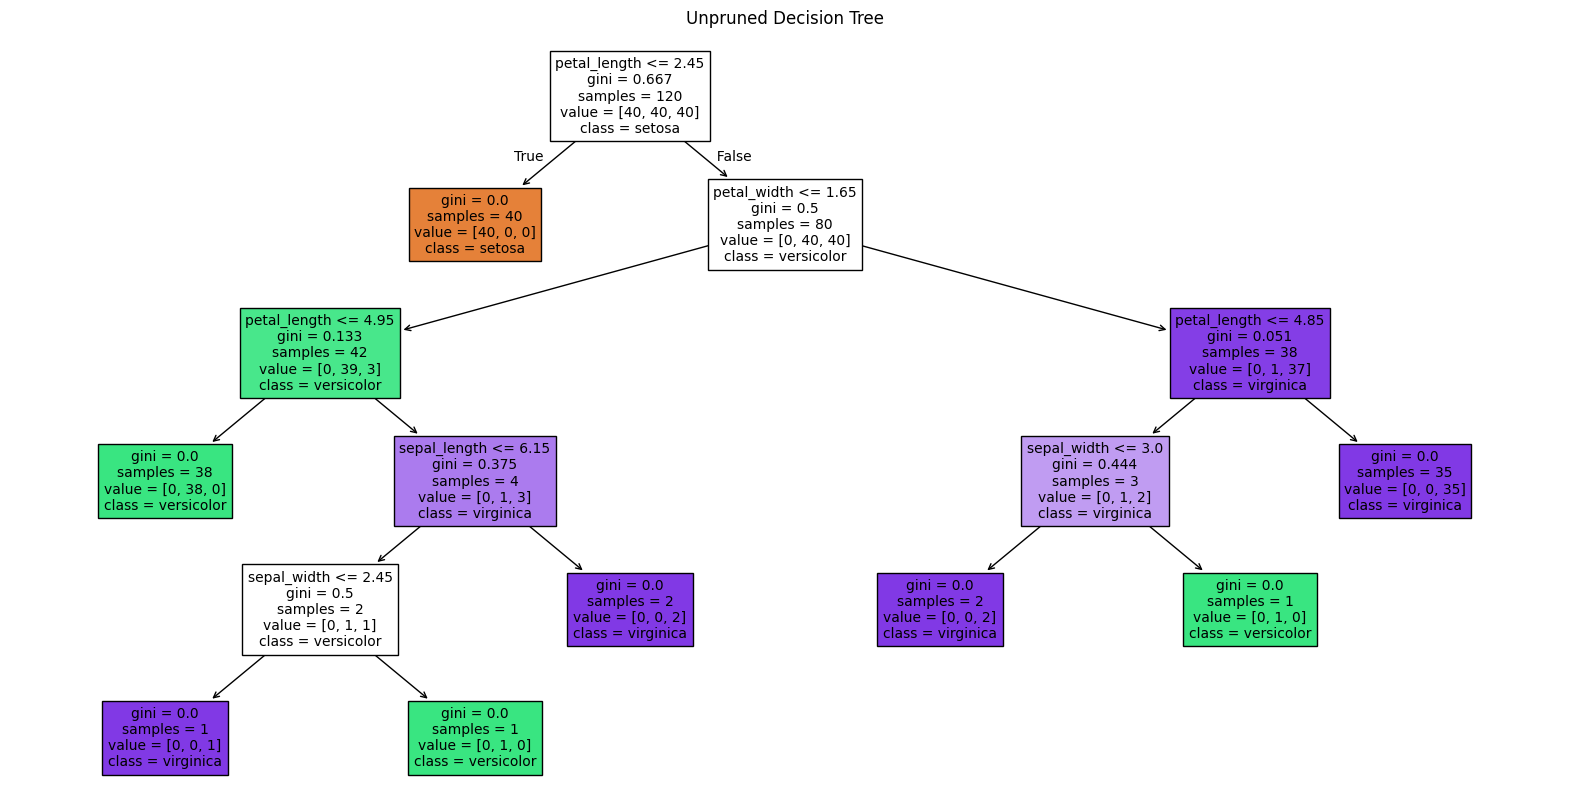

In [9]:
# Visualize the unpruned tree structure
plt.figure(figsize=(20, 10))
plot_tree(tree_unpruned, 
          feature_names=X.columns, 
          class_names=le.classes_, 
          filled=True, 
          fontsize=10)
plt.title('Unpruned Decision Tree')
plt.show()

### Train Pruned Decision Tree (Prevent Overfitting)

In [10]:
# Train pruned decision tree with hyperparameters to prevent overfitting
# max_depth: limits tree depth
# min_samples_split: minimum samples required to split a node
# min_samples_leaf: minimum samples required at a leaf node
tree_pruned = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
tree_pruned.fit(X_train, y_train)

# Evaluate pruned tree
y_pred_pruned = tree_pruned.predict(X_test)
acc_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned, average='weighted')

print("=== Pruned Tree Performance ===")
print(f"Accuracy: {acc_pruned:.4f}")
print(f"F1-Score (weighted): {f1_pruned:.4f}")
print(f"Tree depth: {tree_pruned.tree_.max_depth}")
print(f"Number of leaves: {tree_pruned.tree_.n_leaves}")

=== Pruned Tree Performance ===
Accuracy: 0.9667
F1-Score (weighted): 0.9666
Tree depth: 3
Number of leaves: 5


### Visualize Pruned Tree

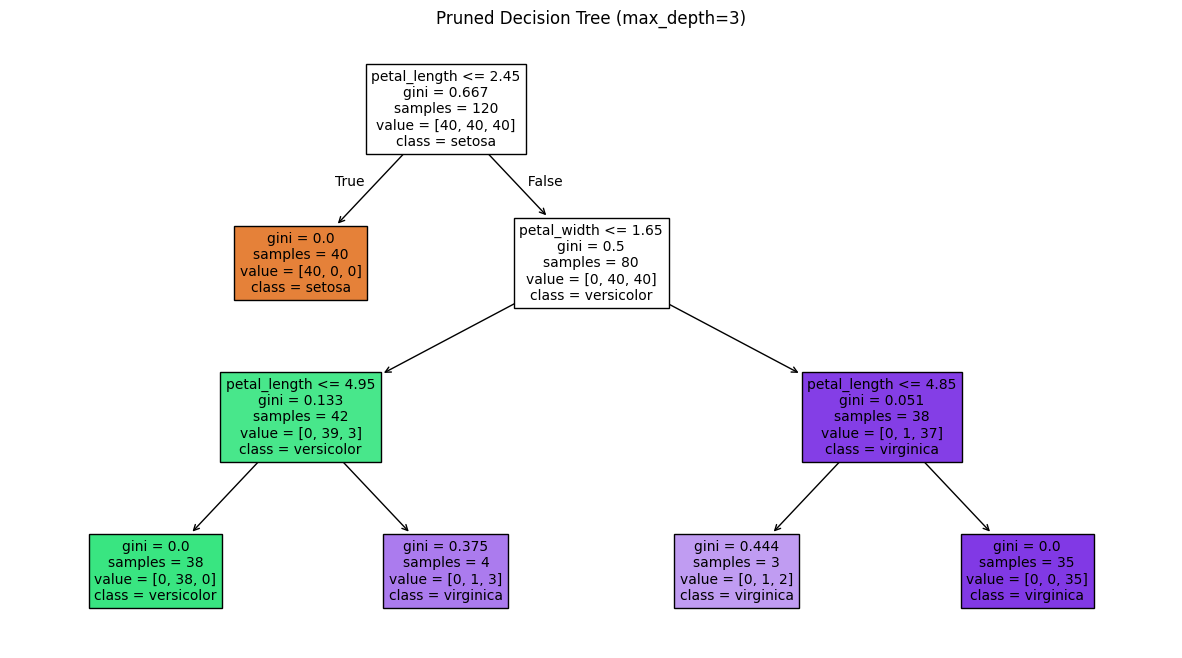

In [11]:
# Visualize the pruned tree structure
plt.figure(figsize=(15, 8))
plot_tree(tree_pruned, 
          feature_names=X.columns, 
          class_names=le.classes_, 
          filled=True, 
          fontsize=10)
plt.title('Pruned Decision Tree (max_depth=3)')
plt.show()

### Compare Unpruned vs Pruned Tree

In [12]:
# Compare performance of unpruned vs pruned tree
comparison = pd.DataFrame({
    'Model': ['Unpruned', 'Pruned'],
    'Accuracy': [acc_unpruned, acc_pruned],
    'F1-Score': [f1_unpruned, f1_pruned],
    'Tree Depth': [tree_unpruned.tree_.max_depth, tree_pruned.tree_.max_depth],
    'Leaves': [tree_unpruned.tree_.n_leaves, tree_pruned.tree_.n_leaves]
})

print("=== Model Comparison ===")
print(comparison.round(4))

print("\nInterpretation:")
print("- Pruned tree is simpler (shallower, fewer leaves)")
print("- Simpler tree reduces overfitting and improves generalization")

=== Model Comparison ===
      Model  Accuracy  F1-Score  Tree Depth  Leaves
0  Unpruned    0.9333    0.9333           5       8
1    Pruned    0.9667    0.9666           3       5

Interpretation:
- Pruned tree is simpler (shallower, fewer leaves)
- Simpler tree reduces overfitting and improves generalization


### Final Evaluation (Pruned Tree)

In [13]:
# Final detailed evaluation of pruned tree
print("=== Final Classification Report (Pruned Tree) ===")
print(classification_report(y_test, y_pred_pruned, target_names=le.classes_))

print(f"\nFinal Accuracy: {acc_pruned:.4f}")
print(f"Final F1-Score (weighted): {f1_pruned:.4f}")

=== Final Classification Report (Pruned Tree) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Final Accuracy: 0.9667
Final F1-Score (weighted): 0.9666
